In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Chemin vers le fichier Excel
file_path = r"C:/Users/ibade/OneDrive/Bureau/Telecom/2A/MODS/Data analysis 1/Data/RawData.xlsx"

# Charger le fichier Excel
df = pd.read_excel(file_path)

print(df.columns)


Index(['Title', 'Title_1', 'ID', 'Rating', 'Release Year', 'Duration',
       'BoxOfficeMojo_Link', 'Worldwide Gross', 'Domestic Gross',
       'International Gross', 'Director', 'Cast and Crew'],
      dtype='object')


In [4]:
#Data cleaning for revenues

df_gross=df.dropna()


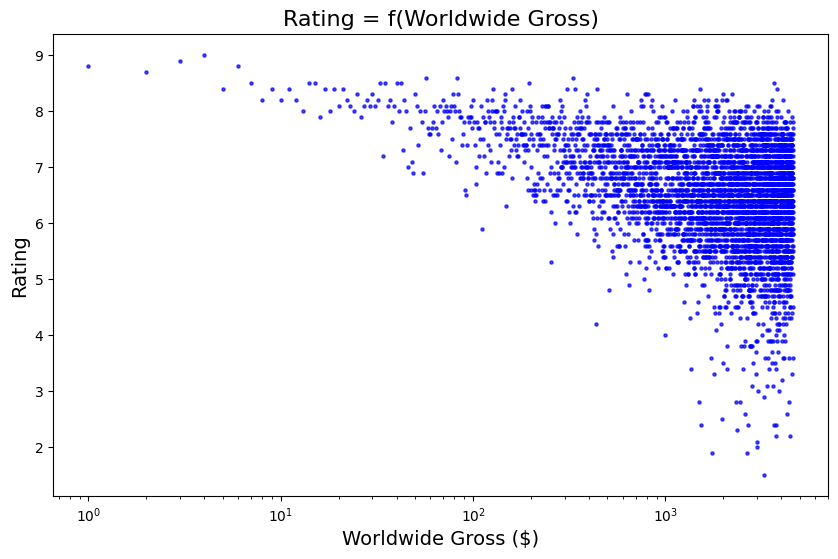

In [5]:

plt.figure(figsize=(10, 6))



plt.scatter(df_gross['Worldwide Gross'], df_gross['Rating'], color='blue', alpha=0.7, s=5)


plt.xscale('log')


plt.title('Rating = f(Worldwide Gross)', fontsize=16)
plt.xlabel('Worldwide Gross ($)', fontsize=14)
plt.ylabel('Rating', fontsize=14)


plt.show()




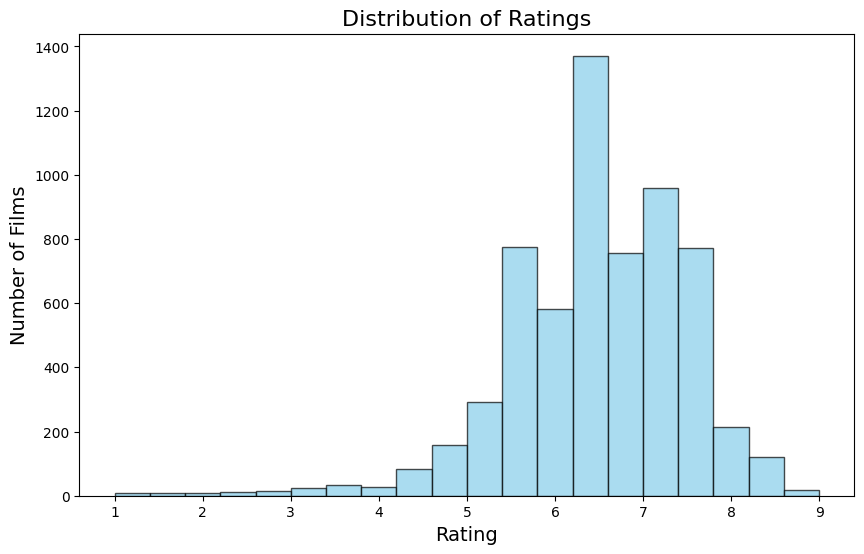

In [6]:
# Create the histogram of the rating distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Rating'].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and a title
plt.title('Distribution of Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Number of Films', fontsize=14)

# Display the plot
plt.show()

In [7]:

# Remove rows where 'Director' or 'Rating' are missing
df_clean = df.dropna(subset=['Director', 'Rating'])

# Group by directors
directors_grouped = df_clean.groupby('Director')

# Calculate the average ratings and the number of films per director
directors_stats = directors_grouped['Rating'].agg(['mean', 'count']).reset_index()

# Filter to keep only directors who have directed more than 5 films
top_directors = directors_stats[directors_stats['count'] > 5]

# Sort directors by average rating in descending order
top_directors_sorted = top_directors.sort_values(by='mean', ascending=False)

# Get the top 10 directors
top_10_directors = top_directors_sorted.head(10)

# Display the top 10 directors
print(top_10_directors)



               Director      mean  count
530   Christopher Nolan  8.220000     10
2295  Quentin Tarantino  8.025000      8
2234      Peter Jackson  7.937500      8
731    Denis Villeneuve  7.775000      8
1848    Martin Scorsese  7.757143      7
1123   Hirokazu Koreeda  7.657143      7
245      Asghar Farhadi  7.657143      7
2501         S. Shankar  7.650000      6
348        Bong Joon Ho  7.633333      6
2111  Nuri Bilge Ceylan  7.628571      7


In [8]:
# Remove rows where 'Director' or 'Worldwide Gross' are missing
df_clean = df.dropna(subset=['Director', 'Worldwide Gross'])

# Convert 'Worldwide Gross' to a numerical value
df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)

# Group by directors
directors_grouped = df_clean.groupby('Director')

# Calculate the sum of worldwide gross and the number of films per director
directors_stats = directors_grouped['Worldwide Gross'].agg(['sum', 'count']).reset_index()

# Filter to keep only directors who have directed more than 5 films
top_directors = directors_stats[directors_stats['count'] > 5]

# Calculate the average worldwide revenue per film
top_directors['average_revenue'] = top_directors['sum'] / top_directors['count']

# Sort directors by average worldwide revenue in descending order
top_directors_sorted = top_directors.sort_values(by='average_revenue', ascending=False)

# Get the top 10 directors
top_10_directors = top_directors_sorted.head(10)

# Display the top 10 directors
print(top_10_directors[['Director', 'average_revenue', 'count']])


               Director  average_revenue  count
189       Anthony Russo     1.142687e+09      6
2017      Peter Jackson     8.192092e+08      8
637         David Yates     8.046906e+08      8
1054        J.J. Abrams     7.766592e+08      6
2281          Sam Raimi     6.736542e+08      6
469   Christopher Nolan     6.179330e+08     10
1726        Michael Bay     5.405614e+08     10
364        Bryan Singer     5.328789e+08      6
1287        Jon Favreau     4.850627e+08      9
827    Francis Lawrence     4.649363e+08      8


C:\Users\ibade\AppData\Local\Temp\ipykernel_15648\2910909465.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\ibade\AppData\Local\Temp\ipykernel_15648\2910909465.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_directors['average_revenue'] = top_directors['sum'] / top_directors['count']


In [9]:
# Remove rows where 'Director', 'Rating', or 'Worldwide Gross' are missing
df_clean = df.dropna(subset=['Director', 'Rating', 'Worldwide Gross'])

# Convert 'Worldwide Gross' to a numerical value
df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)

# Group by directors
directors_grouped = df_clean.groupby('Director')

# Calculate the sum of worldwide gross, average rating, and the number of films per director
directors_stats = directors_grouped['Worldwide Gross'].agg(['sum', 'count']).reset_index()
directors_stats['average_rating'] = directors_grouped['Rating'].mean().reset_index()['Rating']

# Filter to keep only directors who have directed more than 5 films
directors_stats = directors_stats[directors_stats['count'] > 5]

# Calculate the combined index: weighted average of worldwide gross and ratings
# The weights can be adjusted. Here, an equal weight of 0.5 is given to each criterion.
directors_stats['combined_index'] = 0.5 * directors_stats['average_rating'] + 0.5 * (directors_stats['sum'] / directors_stats['count'])

# Sort directors by combined index in descending order
directors_stats_sorted = directors_stats.sort_values(by='combined_index', ascending=False)

# Get the top 10 directors
top_10_directors_combined = directors_stats_sorted.head(10)

# Display the top 10 directors with their combined index
print(top_10_directors_combined[['Director', 'average_rating', 'combined_index', 'count']])


               Director  average_rating  combined_index  count
189       Anthony Russo        7.366667    5.713436e+08      6
2017      Peter Jackson        7.937500    4.096046e+08      8
637         David Yates        7.125000    4.023453e+08      8
1054        J.J. Abrams        7.283333    3.883296e+08      6
2281          Sam Raimi        6.833333    3.368271e+08      6
469   Christopher Nolan        8.220000    3.089665e+08     10
1726        Michael Bay        6.220000    2.702807e+08     10
364        Bryan Singer        7.066667    2.664395e+08      6
1287        Jon Favreau        6.877778    2.425314e+08      9
827    Francis Lawrence        6.887500    2.324682e+08      8


C:\Users\ibade\AppData\Local\Temp\ipykernel_15648\3510218365.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)


In [10]:
# Check if the 'Cast and Crew' and 'Rating' columns exist
if 'Cast and Crew' in df.columns and 'Rating' in df.columns:
    # Clean the columns by removing NA values
    df_clean = df.dropna(subset=['Cast and Crew', 'Rating']).copy()
    
    # Function to extract actor names
    def extract_actors(cast_crew):
        # Split the names by ", " to separate the actors
        actors = [actor.split(" (")[0].strip() for actor in cast_crew.split(",")]
        return actors
    
    # Apply this function to the 'Cast and Crew' column
    df_clean['Actors'] = df_clean['Cast and Crew'].apply(extract_actors)
    
    # Create a DataFrame to link each actor to the rating of their films
    actor_ratings = []
    for _, row in df_clean.iterrows():
        for actor in row['Actors']:
            actor_ratings.append({'Actor': actor, 'Rating': row['Rating']})
    
    # Transform into DataFrame
    actor_ratings_df = pd.DataFrame(actor_ratings)
    
    # Count the number of films per actor
    actor_counts = actor_ratings_df.groupby('Actor').size().rename('Number of Films')
    
    # Keep only actors who have acted in at least 17 films
    valid_actors = actor_counts[actor_counts >= 17].index
    
    # Filter the ratings only for these actors
    filtered_actor_ratings = actor_ratings_df[actor_ratings_df['Actor'].isin(valid_actors)]
    
    # Calculate the average rating per actor
    actor_avg_rating = filtered_actor_ratings.groupby('Actor')['Rating'].mean().rename('Average Rating')
    
    # Combine the average and the number of films into a DataFrame
    actor_summary = pd.concat([actor_avg_rating, actor_counts], axis=1).dropna()
    
    # Sort the results by average rating in descending order
    actor_summary = actor_summary.sort_values(by='Average Rating', ascending=False)
    
    # Select the top 20 actors
    top_actors = actor_summary.head(20)
    
    # Display the results
    print("Top 10 best actors (at least 5 films) by average rating:")
    print(top_actors)
else:
    print("The 'Cast and Crew' or 'Rating' columns do not exist in the DataFrame.")


Top 10 best actors (at least 5 films) by average rating:
                        Average Rating  Number of Films
Actor                                                  
Leonardo DiCaprio             7.747059               17
Robert Downey Jr.             7.248000               25
Ajay Devgn                    7.211765               17
Philip Seymour Hoffman        7.210526               19
Mads Mikkelsen                7.147059               17
Brad Pitt                     7.082143               28
Ryan Gosling                  7.054167               24
Emma Watson                   7.052941               17
Christian Bale                7.050000               30
Tom Cruise                    7.033333               21
Tom Hardy                     7.027778               18
Denzel Washington             7.016667               24
Mark Ruffalo                  7.006667               30
Daniel Craig                  6.995238               21
Daniel Radcliffe              6.990000         

In [11]:
if 'Cast and Crew' in df.columns and 'Worldwide Gross' in df.columns:
    # Clean the data and remove rows with missing values
    df_clean = df.dropna(subset=['Cast and Crew', 'Worldwide Gross']).copy()
    
    # Convert 'Worldwide Gross' to a numeric value if it's not already done
    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)
    
    # Function to extract actor names
    def extract_actors(cast_crew):
        # Split the names by ", " to separate the actors
        actors = [actor.split(" (")[0].strip() for actor in cast_crew.split(",")]
        return actors
    
    # Apply this function to the 'Cast and Crew' column
    df_clean['Actors'] = df_clean['Cast and Crew'].apply(extract_actors)
    
    # Create a DataFrame to link each actor to the box office of their films
    actor_gross = []
    for _, row in df_clean.iterrows():
        for actor in row['Actors']:
            actor_gross.append({'Actor': actor, 'Worldwide Gross': row['Worldwide Gross']})
    
    # Convert to DataFrame
    actor_gross_df = pd.DataFrame(actor_gross)
    
    # Count the number of films per actor
    actor_counts = actor_gross_df.groupby('Actor').size().rename('Number of Films')
    
    # Keep only actors who have acted in at least 20 films
    valid_actors = actor_counts[actor_counts >= 20].index
    
    # Filter the box office data for these actors
    filtered_actor_gross = actor_gross_df[actor_gross_df['Actor'].isin(valid_actors)]
    
    # Calculate the average box office per actor
    actor_avg_gross = filtered_actor_gross.groupby('Actor')['Worldwide Gross'].mean().rename('Average Worldwide Gross')
    
    # Combine the average and the number of films into a DataFrame
    actor_summary_gross = pd.concat([actor_avg_gross, actor_counts], axis=1).dropna()
    
    # Sort the results by average box office in descending order
    actor_summary_gross = actor_summary_gross.sort_values(by='Average Worldwide Gross', ascending=False)
    
    # Select the top 10 actors
    top_actors_gross = actor_summary_gross.head(10)
    
    # Display the results
    print("Top 10 best actors (at least 5 films) by average worldwide gross:")
    print(top_actors_gross)
else:
    print("The 'Cast and Crew' or 'Worldwide Gross' columns do not exist in the DataFrame.")


Top 10 best actors (at least 5 films) by average worldwide gross:
                   Average Worldwide Gross  Number of Films
Actor                                                      
Robert Downey Jr.             6.169708e+08               25
Vin Diesel                    4.360692e+08               21
Chris Evans                   4.204963e+08               28
Tom Cruise                    4.119024e+08               21
Will Smith                    3.617283e+08               20
Dwayne Johnson                3.285372e+08               37
Mark Ruffalo                  3.172368e+08               29
Jack Black                    2.922555e+08               24
Johnny Depp                   2.838059e+08               33
Daniel Craig                  2.761690e+08               21


In [12]:
if 'Cast and Crew' in df.columns and 'Rating' in df.columns and 'Worldwide Gross' in df.columns:
    # Clean the data by removing rows with missing values
    df_clean = df.dropna(subset=['Cast and Crew', 'Rating', 'Worldwide Gross']).copy()
    
    # Convert 'Worldwide Gross' to a numeric value
    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)
    
    # Function to extract actors
    def extract_actors(cast_crew):
        # Split the names by ", " to separate the actors
        actors = [actor.split(" (")[0].strip() for actor in cast_crew.split(",")]
        return actors
    
    # Apply this function to the 'Cast and Crew' column
    df_clean['Actors'] = df_clean['Cast and Crew'].apply(extract_actors)
    
    # Create a DataFrame to link each actor to their ratings and worldwide gross
    actor_data = []
    for _, row in df_clean.iterrows():
        for actor in row['Actors']:
            actor_data.append({'Actor': actor, 'Rating': row['Rating'], 'Worldwide Gross': row['Worldwide Gross']})
    
    # Convert to DataFrame
    actor_data_df = pd.DataFrame(actor_data)
    
    # Count the number of films per actor
    actor_counts = actor_data_df.groupby('Actor').size().rename('Number of Films')
    
    # Keep only actors who have acted in at least 5 films
    valid_actors = actor_counts[actor_counts >= 5].index
    
    # Filter the data for these actors
    filtered_actor_data = actor_data_df[actor_data_df['Actor'].isin(valid_actors)]
    
    # Calculate the average ratings and worldwide gross
    actor_avg_rating = filtered_actor_data.groupby('Actor')['Rating'].mean().rename('Average Rating')
    actor_avg_gross = filtered_actor_data.groupby('Actor')['Worldwide Gross'].mean().rename('Average Worldwide Gross')
    
    # Combine the results into a DataFrame
    actor_summary = pd.concat([actor_avg_rating, actor_avg_gross, actor_counts], axis=1).dropna()
    
    # Normalize the worldwide gross to combine it with the ratings
    max_gross = actor_summary['Average Worldwide Gross'].max()
    max_rating = actor_summary['Average Rating'].max()
    actor_summary['Normalized Gross'] = actor_summary['Average Worldwide Gross'] / max_gross
    actor_summary['Normalized Rating'] = actor_summary['Average Rating'] / max_rating
    
    # Calculate a weighted score (50% for worldwide gross and 50% for ratings)
    actor_summary['Weighted Score'] = 0.5 * actor_summary['Normalized Gross'] + 0.5 * actor_summary['Normalized Rating']
    
    # Sort the actors by their weighted score
    top_actors = actor_summary.sort_values(by='Weighted Score', ascending=False)
    
    # Select the top 10 actors
    top_10_actors = top_actors.head(10)
    
    # Display the results
    print("Top 10 best actors (combining worldwide gross and ratings):")
    print(top_10_actors[['Average Rating', 'Average Worldwide Gross', 'Number of Films', 'Weighted Score']])
else:
    print("The 'Cast and Crew', 'Rating', or 'Worldwide Gross' columns do not exist in the DataFrame.")


Top 10 best actors (combining worldwide gross and ratings):
                   Average Rating  Average Worldwide Gross  Number of Films  \
Actor                                                                         
Rupert Grint             7.588889             8.688823e+08                9   
Daisy Ridley             6.533333             7.521474e+08                6   
Ian McKellen             7.638462             6.304552e+08               13   
John Boyega              6.585714             6.919840e+08                7   
Robert Downey Jr.        7.248000             6.169708e+08               25   
Chris Hemsworth          6.812500             6.363749e+08               16   
Emma Watson              7.052941             5.868424e+08               17   
Chris Pratt              6.894118             5.505941e+08               17   
Tom Holland              6.988889             5.289155e+08                9   
Orlando Bloom            7.333333             4.899266e+08             

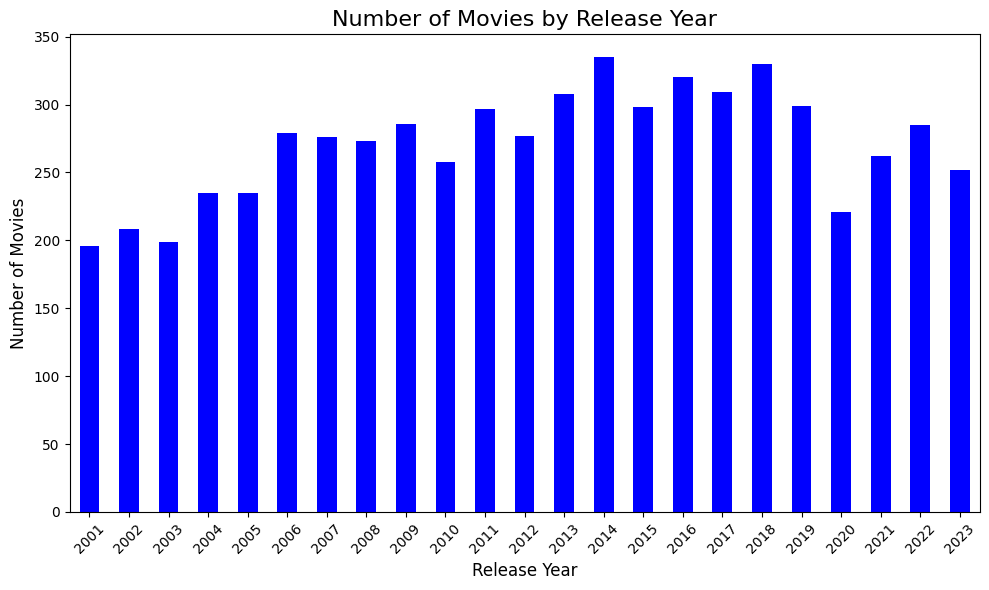

In [13]:
# Example of a DataFrame with movie data (assuming the DataFrame is already loaded)
if 'Title' in df.columns and 'Release Year' in df.columns:
    # Clean the data by removing rows with missing values in 'Release Year'
    df_clean = df.dropna(subset=['Release Year']).copy()

    # Count the number of films per year
    films_per_year = df_clean.groupby('Release Year').size()

    # Create a plot
    plt.figure(figsize=(10, 6))
    films_per_year.plot(kind='bar', color='blue')

    # Add titles and labels
    plt.title('Number of Movies by Release Year', fontsize=16)
    plt.xlabel('Release Year', fontsize=12)
    plt.ylabel('Number of Movies', fontsize=12)

    # Display the plot
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("The columns 'Title' or 'Release Year' do not exist in the DataFrame.")


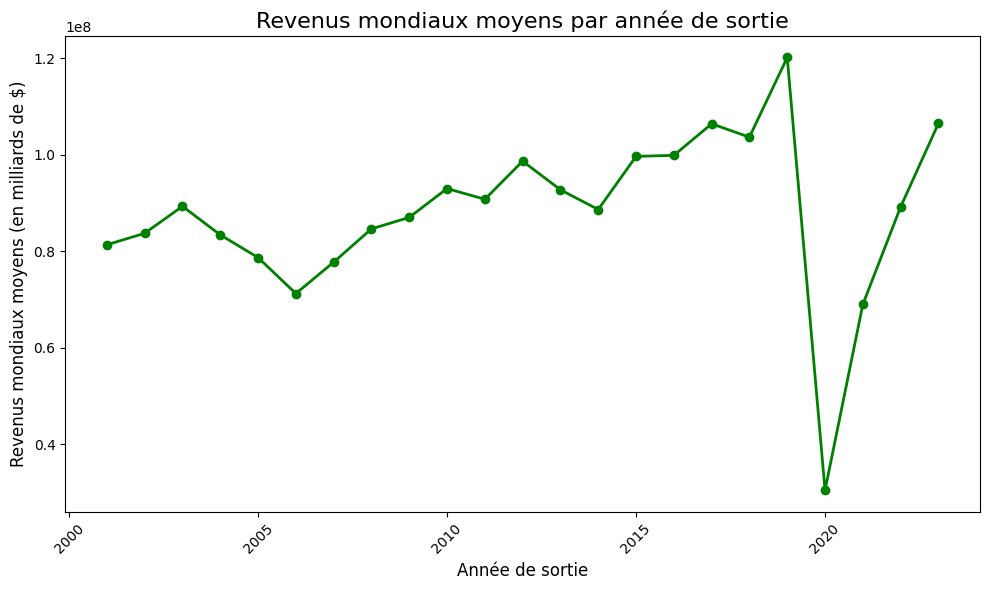

In [14]:
# Exemple de DataFrame avec les données de films (en supposant que le DataFrame est déjà chargé)
if 'Release Year' in df.columns and 'Worldwide Gross' in df.columns:
    # Nettoyage des données, suppression des lignes avec des valeurs manquantes dans 'Release Year' et 'Worldwide Gross'
    df_clean = df.dropna(subset=['Release Year', 'Worldwide Gross']).copy()

    # Convertir 'Worldwide Gross' en une valeur numérique si ce n'est pas déjà fait
    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)

    # Calculer les revenus mondiaux moyens par année de sortie
    revenue_per_year = df_clean.groupby('Release Year')['Worldwide Gross'].mean()

    # Créer un graphique
    plt.figure(figsize=(10, 6))
    revenue_per_year.plot(kind='line', color='green', marker='o', linestyle='-', linewidth=2, markersize=6)

    # Ajouter des titres et labels
    plt.title('Revenus mondiaux moyens par année de sortie', fontsize=16)
    plt.xlabel('Année de sortie', fontsize=12)
    plt.ylabel('Revenus mondiaux moyens (en milliards de $)', fontsize=12)

    # Afficher le graphique
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Les colonnes 'Release Year' ou 'Worldwide Gross' n'existent pas dans le DataFrame.")

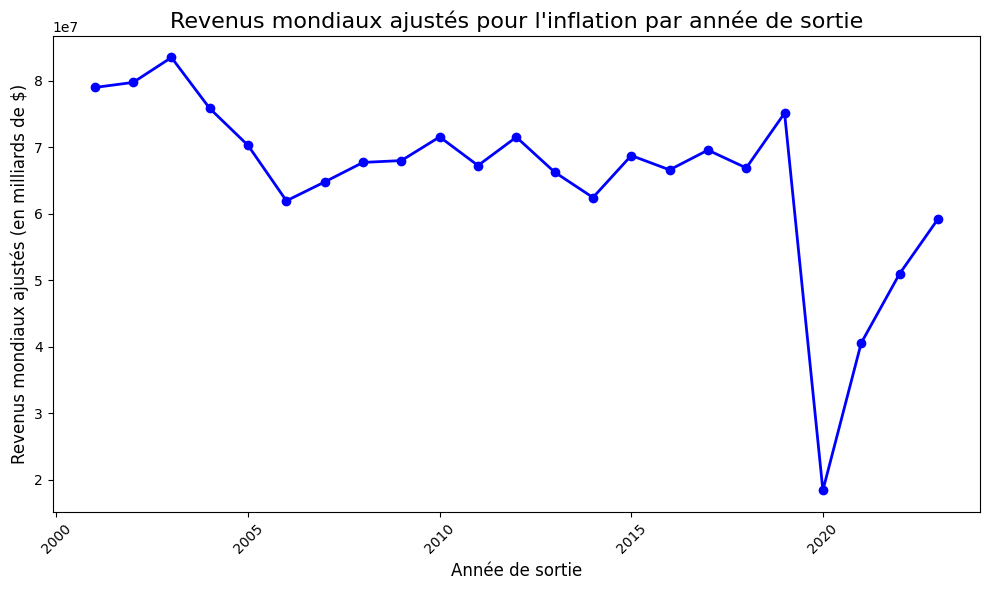

In [15]:
# Exemple d'indice des prix à la consommation (IPC) par année (en valeur relative par rapport à une année de référence)
# Pour un calcul réel, vous devrez obtenir l'IPC historique d'une source fiable (par exemple, des banques centrales ou des sites économiques)
inflation_index = {
    2000: 1.00,
    2001: 1.03,
    2002: 1.05,
    2003: 1.07,
    2004: 1.10,
    2005: 1.12,
    2006: 1.15,
    2007: 1.20,
    2008: 1.25,
    2009: 1.28,
    2010: 1.30,
    2011: 1.35,
    2012: 1.38,
    2013: 1.40,
    2014: 1.42,
    2015: 1.45,
    2016: 1.50,
    2017: 1.53,
    2018: 1.55,
    2019: 1.60,
    2020: 1.65,
    2021: 1.70,  # Hypothétique valeur
    2022: 1.75,  # Hypothétique valeur
    2023: 1.80   # Hypothétique valeur
}

# Exemple de DataFrame avec les colonnes 'Release Year' et 'Worldwide Gross'
if 'Release Year' in df.columns and 'Worldwide Gross' in df.columns:
    # Nettoyer les données, supprimer les lignes avec des valeurs manquantes dans 'Release Year' et 'Worldwide Gross'
    df_clean = df.dropna(subset=['Release Year', 'Worldwide Gross']).copy()

    # Convertir 'Worldwide Gross' en une valeur numérique
    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)

    # Ajouter une colonne pour l'indice d'inflation pour chaque film
    df_clean['Inflation Index'] = df_clean['Release Year'].map(inflation_index)

    # Calculer les revenus mondiaux ajustés pour l'inflation
    df_clean['Adjusted Worldwide Gross'] = df_clean['Worldwide Gross'] / df_clean['Inflation Index']

    # Calculer les revenus mondiaux ajustés moyens par année de sortie
    revenue_per_year_adjusted = df_clean.groupby('Release Year')['Adjusted Worldwide Gross'].mean()

    # Créer un graphique des revenus mondiaux ajustés par année de sortie
    plt.figure(figsize=(10, 6))
    revenue_per_year_adjusted.plot(kind='line', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)

    # Ajouter des titres et labels
    plt.title('Revenus mondiaux ajustés pour l\'inflation par année de sortie', fontsize=16)
    plt.xlabel('Année de sortie', fontsize=12)
    plt.ylabel('Revenus mondiaux ajustés (en milliards de $)', fontsize=12)

    # Afficher le graphique
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Les colonnes 'Release Year' ou 'Worldwide Gross' n'existent pas dans le DataFrame.")